# Atividade 3 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 19 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural convolucional para classificar o _Stanford Dogs Dataset_, um dataset com imagens de 120 raças de cachorro de todo o mundo e mais de 20 mil imagens para treino e teste.

## Material de Referência para Estudo

- http://vision.stanford.edu/aditya86/ImageNetDogs/


## Prazos importantes

- Data de entrega: 23/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Quartetos (a interseção com grupos anteriores deve ter tamanho máximo igual a 2)

In [2]:
import csv
import kagglehub
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Obtenção do dataset

- A tarefa a ser considerada é uma tarefa de classificação multiclasse
- A documentação oficial do dataset pode ser obtida aqui: http://vision.stanford.edu/aditya86/ImageNetDogs/
- Vamos usar essa versão do Kaggle em que as imagens e rótulos já estão organizados:
  https://www.kaggle.com/datasets/miljan/stanford-dogs-dataset-traintest
- Instale a API do Kaggle e faça o download do dataset usando Python
- Organize o nome das classes, retire o identificador "n[id]" do início das pastas

In [2]:
kagglehub.login()

In [3]:
dataset_folder = "./data"
train_folder = dataset_folder + "/cropped/cropped/train"
test_folder = dataset_folder + "/cropped/cropped/test"

In [4]:
path = kagglehub.dataset_download("miljan/stanford-dogs-dataset-traintest", output_dir=dataset_folder)

def remove_id_from_names(folder):
    try:
        for filename in os.listdir(folder):
            if os.path.isdir(os.path.join(folder, filename)):
                remove_id_from_names(os.path.join(folder, filename))

            old_name = os.path.join(folder, filename)
            new_name = os.path.join(folder, filename[10:])
            
            os.rename(old_name, new_name)
    except OSError as err:
        # erro de arquivo ja existente.
        # acontece quando roda a celula mais de uma vez.
        if err.errno == 39:
            pass
        else:
            raise
    print("Done removing ids from names inside " + folder)

remove_id_from_names(train_folder)
remove_id_from_names(test_folder)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 393M/393M [13:51<00:00, 496kB/s]

Extracting files...


Done removing ids from names inside ./data/cropped/cropped/train/n02111277-Newfoundland
Done removing ids from names inside ./data/cropped/cropped/train/n02085620-Chihuahua
Done removing ids from names inside ./data/cropped/cropped/train/n02091032-Italian_greyhound
Done removing ids from names inside ./data/cropped/cropped/train/n02095570-Lakeland_terrier
Done removing ids from names inside ./data/cropped/cropped/train/n02104365-schipperke
Done removing ids from names inside ./data/cropped/cropped/train/n02108422-bull_mastiff
Done removing ids from names inside ./data/cropped/cropped/train/n02099712-Labrador_retriever
Done removing ids from names inside ./data/cropped/cropped/train/n02101388-Brittany_spaniel
Done removing ids from names inside ./data/cropped/cropped/train/n02109047-Great_Dane
Done removing ids from names inside ./data/cropped/cropped/train/n02100735-English_setter
Done removing ids from names inside ./data/cropped/cropped/train/n02085782-Japanese_spaniel
Done removing 

# Transformações na Entrada, Image Handler e Data Loader

- As imagens precisam ser padronizadas, vamos usar as dimensões 224x224 e a normalização das cores
- Transformação das Imagens: https://docs.pytorch.org/vision/0.8/transforms.html
- Operações: Redimensionamento, Para Tensor e Normalização ([-1,1] com média 0.5 e desvio padrão de 0.5)
- Criar um ImageHandler para cada pasta (treino/teste):
  - https://docs.pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html#torchvision.datasets.ImageFolder
- Para o treinamento: criar um Data loader com tamanho de lote igual a 32 e randomização
- https://docs.pytorch.org/docs/stable/data.html
- Para o teste: criar um Data loader com lote de tamanho igual a 1 e sem randomização

In [5]:
resize = transforms.Resize((224, 224))
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))

transforms_compose = transforms.Compose([
    resize,
    to_tensor,
    normalize
])

train_handler = ImageFolder(root=train_folder, transform=transforms_compose)
test_handler = ImageFolder(root=test_folder, transform=transforms_compose)

train_loader = DataLoader(train_handler, batch_size=32, shuffle=True, num_workers=6, pin_memory=True)
test_loader = DataLoader(test_handler, batch_size=1, shuffle=False)

## Entendendo o Image Handler (dataset.ImageFolder) DataLoader

- Responda ao que se pede:
    1. Qual o papel do ImageHandler nesse contexto?
    2. E do DataLoader?
    3. Por que o tamanho do batch não pode ser todo o conjunto de dados?
    4. Por que o DataLoader do treinamento precisa de aleatoriedade?
    5. Por que o DataLoader do teste deve ter batch igual a 1 e sem aleatoriedade?

**Resposta:**
1. Ele serve para carregar as classes e exemplos do dataset, aplicar as transformações nas imagens e gerar o dataset no contexto do PyTorch
2. Serve para carregar e acessar o dataset gerado pelo ImageFolder e definir alguns hiperparâmetros como o tamanho do batch
3. Porque uma rede neural com um batch menor usa menos memória no treinamento e geralmente o conclui em menos tempo
4. Para evitar que o modelo fique enviesado
5. O batch igual a 1 serve para reduzir o tempo e o uso de memória. Testar sem aleatoriedade serve para garantir que os testes sempre são os mesmos, garantindo que os resultados de treinamento diferentes possam ser comparados

## Construindo sua primeira CNN: AlexNet

- Construa, camada a camada, a CNN AlexNet, vencedora do ImageNet 2012
- Arquitetura da AlexNet é dada a seguir:
1. Conv 1: 96 filtros de tamanho $11 \times 11$, com um stride (passo) de 4.
2. Max Pool 1: Redução espacial com janelas de $3 \times 3$ e stride 2.
3. Conv 2: 256 filtros de $5 \times 5$ com padding para manter a dimensão.
4. Max Pool 2: Outra redução de $3 \times 3$ com stride 2.
5. Conv 3, 4 e 5: Camadas convolucionais puras (sem pooling entre elas) com 384, 384 e 256 filtros de $3 \times 3$, respectivamente.
6. Max Pool 3: Última redução antes das camadas densas.
7. Camada de adaptação para classificação: Adaptive Average Pooling Bidimensional 6x6
8. FC 6 e 7: Duas camadas densas com 4096 neurônios cada, utilizando Dropout de 0.5 para reduzir o overfitting.
9. FC 8 (Saída): Camada final com ativação Softmax. Ajuste a camada de saída para o número de classes do problema encontrado.

### Sumário do Modelo

- Apresente o sumário do modelo, indicando quantos parâmetros ele possui e quantos destes são treináveis.


### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.MaxPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.activation.ReLU.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.AdaptiveAvgPool2d.html
- https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.dropout.Dropout.html





In [6]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.convolution = nn.Sequential(
            nn.Conv2d(3, 96, 11, stride=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2),
            nn.Conv2d(96, 256, 5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2),
            nn.Conv2d(256, 384, 3),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, 3),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, 3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2)
        )
        self.adapt = nn.AdaptiveAvgPool2d(6)
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(9216, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.convolution(x)
        x = self.adapt(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [7]:
model = AlexNet(num_classes=120)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(total_params)
print(trainable_params)

58772984
58772984


## Configuração do Treino

- 120 épocas
- Otimizador: Mini-batch SGD com Momentum (tal qual no paper original da AlexNet)
- Zere os gradientes do otimizador
- Lotes de 32
- Taxa de aprendizado: 10^(-3)
- Momentum: 0.9
- Função de perda: Entropia Cruzada Categórica
- Caso tenha disponibilidade, acelere o treino com GPU

### Monitorando o Treinamento

- Ao longo das épocas, armazene o loss e a acurácia no treino em um arquivo csv

#### Links Úteis

- https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
- https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html

In [8]:
device = torch.device("cuda")

In [9]:
model = AlexNet(num_classes=120).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

num_epochs = 120
history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        if (i + 1) % 100 == 0:
            print(f"  Epoch {epoch+1} - Batch {i+1}/375 - Loss parcial: {running_loss/total:.4f}")

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    history.append((epoch + 1, epoch_loss, epoch_acc))
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Acc: {epoch_acc:.4f}")

  Epoch 1 - Batch 100/375 - Loss parcial: 4.7874
  Epoch 1 - Batch 200/375 - Loss parcial: 4.7875
  Epoch 1 - Batch 300/375 - Loss parcial: 4.7876
Epoch [1/120] - Loss: 4.7877 - Acc: 0.0080
  Epoch 2 - Batch 100/375 - Loss parcial: 4.7876
  Epoch 2 - Batch 200/375 - Loss parcial: 4.7876
  Epoch 2 - Batch 300/375 - Loss parcial: 4.7876
Epoch [2/120] - Loss: 4.7876 - Acc: 0.0083
  Epoch 3 - Batch 100/375 - Loss parcial: 4.7874
  Epoch 3 - Batch 200/375 - Loss parcial: 4.7874
  Epoch 3 - Batch 300/375 - Loss parcial: 4.7875
Epoch [3/120] - Loss: 4.7875 - Acc: 0.0076
  Epoch 4 - Batch 100/375 - Loss parcial: 4.7871
  Epoch 4 - Batch 200/375 - Loss parcial: 4.7873
  Epoch 4 - Batch 300/375 - Loss parcial: 4.7873
Epoch [4/120] - Loss: 4.7874 - Acc: 0.0083
  Epoch 5 - Batch 100/375 - Loss parcial: 4.7871
  Epoch 5 - Batch 200/375 - Loss parcial: 4.7872
  Epoch 5 - Batch 300/375 - Loss parcial: 4.7872
Epoch [5/120] - Loss: 4.7872 - Acc: 0.0083
  Epoch 6 - Batch 100/375 - Loss parcial: 4.7870
 

In [10]:
with open("training_log.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "loss", "accuracy"])
    writer.writerows(history)

## Métricas do Treinamento

- Elabore um gráfico com a função de perda ao longo das épocas
- Elabore um gráfico com a acurácia do conjunto de treino ao longo das épocas
- Responda: O treino foi eficiente?

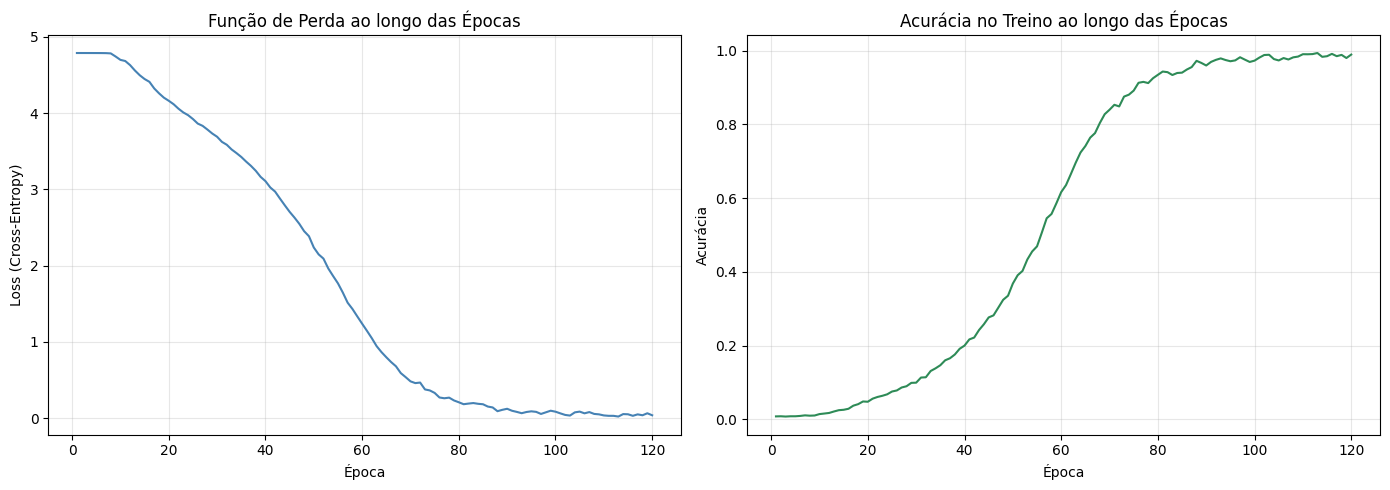

In [11]:
df = pd.read_csv("training_log.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df["epoch"], df["loss"], color="steelblue")
ax1.set_title("Função de Perda ao longo das Épocas")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss (Cross-Entropy)")
ax1.grid(True, alpha=0.3)

ax2.plot(df["epoch"], df["accuracy"], color="seagreen")
ax2.set_title("Acurácia no Treino ao longo das Épocas")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Resposta: O treino foi eficiente?
Sim. A função de perda partiu de ~4.78, ou seja, predição aleatória uniforme entre as 120 classes e convergiu para bem próximo de 0.0 na época 120. A acurácia no conjunto de treino subiu de ~0.7% para ~99.5%.

Observação a se destacar:
Ao primeiro realizar esse treinamento, utilizamos um nn.Softmax(1) explícito na camada de saída da AlexNet. Porém, ao monitorar as primeiras épocas, percebemos que a loss permanecia estagnada em ~4.7875, ou seja, predição aleatória e a acurácia não saía de ~0.8%. Ao investigar a causa, identificamos que a nn.CrossEntropyLoss do PyTorch já aplica internamente um LogSoftmax. Com o Softmax explícito na rede, a operação era aplicada duas vezes: os logits passavam por Softmax (comprimindo os valores entre 0 e 1) e depois por LogSoftmax novamente dentro da loss. Isso achatava drasticamente os gradientes, tornando os passos de atualização dos pesos insignificantes. A solução foi remover o nn.Softmax(1) da arquitetura e deixar a CrossEntropyLoss operar diretamente sobre os logits crus, o que resultou na convergência observada nos gráficos acima.

### Persista o modelo

- Salvar o modelo com os pesos após o aprendizado é uma estratégia importante para posteriormente utilizá-lo para inferência ou para análises comparativas
- Nesta atividade, salve o modelo em disco e recupere-o para efetuar a avaliação no conjunto de testes

In [12]:
torch.save(model.state_dict(), "alexnet_stanford_dogs.pth")
print("Modelo salvo com sucesso em alexnet_stanford_dogs.pth")

Modelo salvo com sucesso em alexnet_stanford_dogs.pth


In [13]:
model_loaded = AlexNet(num_classes=120).to(device)
model_loaded.load_state_dict(torch.load("alexnet_stanford_dogs.pth", map_location=device))
model_loaded.eval()
print("Modelo carregado e em modo de avaliação.")

Modelo carregado e em modo de avaliação.


## Avaliação do Modelo

- Faça as inferências do modelo para o conjunto de testes e cálcule as métricas para uma tarefa de classificação multiclasse
- Elabore uma matriz de confusão
- Escolha três exemplos aleatórios do conjunto de testes, exiba-as e mostre também as top-3 probabilidades de classificação

In [ ]:
all_preds = []
all_labels = []

model_loaded.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_loaded(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.append(predicted.cpu().item())
        all_labels.append(labels.item())

acc_test = accuracy_score(all_labels, all_preds)
print(f"Acurácia no conjunto de teste: {acc_test:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=test_handler.classes, zero_division=0))

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(22, 20))
sns.heatmap(cm, cmap="Blues", xticklabels=test_handler.classes,
            yticklabels=test_handler.classes)
plt.title("Matriz de Confusão — AlexNet no Stanford Dogs Dataset")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.xticks(fontsize=4, rotation=90)
plt.yticks(fontsize=4, rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
indices = random.sample(range(len(test_handler)), 3)
class_names = test_handler.classes

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, idx in zip(axes, indices):
    image, label = test_handler[idx]
    with torch.no_grad():
        output = model_loaded(image.unsqueeze(0).to(device))
        probabilities = torch.nn.functional.softmax(output, dim=1)

    probs, top3_idx = torch.topk(probabilities, 3, dim=1)

    img_display = image.permute(1, 2, 0) * 0.5 + 0.5

    ax.imshow(img_display.clamp(0, 1).numpy())
    title = f"Real: {class_names[label]}\n"
    for p, c in zip(probs[0], top3_idx[0]):
        title += f"{class_names[c.item()]}: {p.item():.2%}\n"
    ax.set_title(title, fontsize=8)
    ax.axis("off")

plt.suptitle("3 Exemplos Aleatórios do Teste com Top-3 Probabilidades", fontsize=12)
plt.tight_layout()
plt.show()

## Parecer Avaliativo

- Elabore um parecer sobre o desempenho do modelo, elencando vantagens e limitações
- Faça a sugestão de três estratégias a serem incorporadas no modelo ou em seu treinamento para que haja melhoria de desempenho

### Parecer sobre o Desempenho do Modelo

#### Resultados Obtidos

O modelo AlexNet treinado do zero por 120 épocas alcançou **99.5% de acurácia no conjunto de treino**, porém apenas **~24% no conjunto de teste**. Essa discrepância de 75 pontos percentuais configura um caso severo de **overfitting**: o modelo memorizou os exemplos de treino, mas não conseguiu generalizar para imagens novas. Ainda assim, 24% está significativamente acima do acaso (que seria ~0.83% para 120 classes), indicando o aprendizado real de features visuais.

Porém vale lembrar que o Stanford Dogs Dataset é considerado um benchmark de classificação fina, onde as diferenças entre classes são sutis: distinguir um Norfolk Terrier de um Norwich Terrier exige captar variações mínimas em formato de orelha e textura de pelagem.

#### Observação sobre o Softmax na Saída

Conforme já detalhado na seção de métricas do treinamento, a aplicação duplicada do Softmax (explícito na rede + implícito na CrossEntropyLoss) foi identificada e corrigida durante o desenvolvimento, consideramos este um aprendizado diferencial da atividade.

#### Vantagens do Modelo

- **Arquitetura consolidada e didática:** a AlexNet é historicamente relevante como marco do deep learning em visão computacional (vencedora do ImageNet 2012) e sua simplicidade facilita a compreensão do pipeline convolucional completo.
- **Convergência estável:** com SGD + Momentum 0.9 e lr=10^(-3), a loss caiu de forma segura após a fase inicial, sem oscilações que indicariam instabilidade numérica ou learning rate excessiva.
- **Dropout como regularização:** as camadas de Dropout de 0.5 nas FC layers representam uma forma válida de regularização.

#### Limitações Identificadas

- **Overfitting severo (99.5% treino vs. ~24% teste):** o modelo possui 60 milhões de parâmetros treináveis para um conjunto de apenas ~12.000 imagens de treino. Essa desproporção entre a capacidade do modelo e o volume de dados é a causa raiz do overfitting, pois a rede tem capacidade mais do que suficiente para memorizar todo o dataset sem precisar aprender representações generalizáveis.
- **Ausência de Data Augmentation:** o pipeline de transformações aplicou apenas Resize, ToTensor e Normalize, sem nenhuma técnica de aumento de dados. Assim o modelo viu exatamente as mesmas imagens em todas as 120 épocas, tornando simples a memorização.
- **Arquitetura datada:** a AlexNet, por ser de 2012, não incorpora avanços posteriores como Batch Normalization, blocos residuais ou mecanismos de atenção, que melhoram significativamente tanto a velocidade de convergência quanto a capacidade de generalização.

#### Três Estratégias para Melhoria de Desempenho

1. **Data Augmentation agressivo:** incorporar ao pipeline de treino transformações como `RandomHorizontalFlip`, `RandomRotation(15)`, `RandomResizedCrop(224)` e `ColorJitter(brightness=0.2, contrast=0.2)`. Assim seriam geradas variações sintéticas de cada imagem a cada época, efetivamente multiplicando o tamanho do dataset sem custo de coleta.

2. **Transfer Learning com fine-tuning:** utilizar uma rede pré-treinada no ImageNet como extrator de features, congelando as camadas convolucionais iniciais e treinando apenas as camadas finais. Isso aproveitaria representações visuais genéricas já aprendidas em milhões de imagens. Em benchmarks publicados, essa abordagem atinge >80% de acurácia no Stanford Dogs ([referência](https://www.kaggle.com/code/teyang/dog-breeds-classification-using-transfer-learning)).

3. **Learning Rate Scheduler + Early Stopping:** implementar um scheduler como `ReduceLROnPlateau` (que reduz a taxa de aprendizado quando a loss de validação estagna) combinado com um split de validação (e.g., 80/20 do treino) e Early Stopping para interromper o treinamento quando a acurácia de validação parar de melhorar. Isso evitaria que o modelo continuasse memorizando o treino nas épocas finais, preservando uma acurácia concisa.
